In [1]:
import os
import sys
sys.path.insert(
    0, os.path.abspath('../../')
)

import json
import yaml

from pathlib import Path
from rich.console import Console
from rich.table import Table

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
root_dir = Path("../../").resolve()
print("Root directory:", root_dir)

Root directory: /home/hgkahng/Workspaces/soft-prompt


## Load oracle data

In [3]:
from typing import Union, Tuple

def load_oracle_imdb_data(directory: Union[str, Path]) -> Tuple[np.ndarray, np.ndarray]:
    
    _directory = Path(directory).resolve()
    X_train = np.load(_directory / "train.features.npy")
    y_train = np.load(_directory / "train.labels.npy")
    X_test = np.load(_directory / "test.features.npy")
    y_test = np.load(_directory / "test.labels.npy")
    
    return (X_train, y_train, X_test, y_test)

In [4]:
emb_save_dir = root_dir / "data/imdb/embeddings/openai/text-embedding-3-small"
X_train, y_train, X_test, y_test = load_oracle_imdb_data(emb_save_dir)

In [5]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((25000, 1536), (25000,), (25000, 1536), (25000,))

## Train Oracle Model
- We assume that training on $\mathcal{D}_\text{real}$ produces a pseudo-oracle model.

In [6]:
!pip show scikit-learn

Name: scikit-learn
Version: 1.6.1
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License: BSD 3-Clause License

 Copyright (c) 2007-2024 The scikit-learn developers.
 All rights reserved.

 Redistribution and use in source and binary forms, with or without
 modification, are permitted provided that the following conditions are met:

 * Redistributions of source code must retain the above copyright notice, this
   list of conditions and the following disclaimer.

 * Redistributions in binary form must reproduce the above copyright notice,
   this list of conditions and the following disclaimer in the documentation
   and/or other materials provided with the distribution.

 * Neither the name of the copyright holder nor the names of its
   contributors may be used to endorse or promote products derived from
   this software without specific prior written permission.

 THIS SOFTWARE IS PROVIDED BY THE COPYR

In [7]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.frozen import FrozenEstimator
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay

In [8]:
oracle = LogisticRegressionCV(
    Cs=10, cv=5, solver='lbfgs', max_iter=1000, n_jobs=16,
    random_state=42, 
)
oracle.fit(X_train, y_train);

In [9]:
calibrated_oracle = CalibratedClassifierCV(
    estimator=FrozenEstimator(oracle),
    cv=10, n_jobs=16
)
calibrated_oracle.fit(X_train, y_train);

In [10]:
df_test = pd.DataFrame.from_dict(
    {
        'y_test': y_test,
        'y_test_pred': oracle.predict_proba(X_test)[:, 1]
    }
)

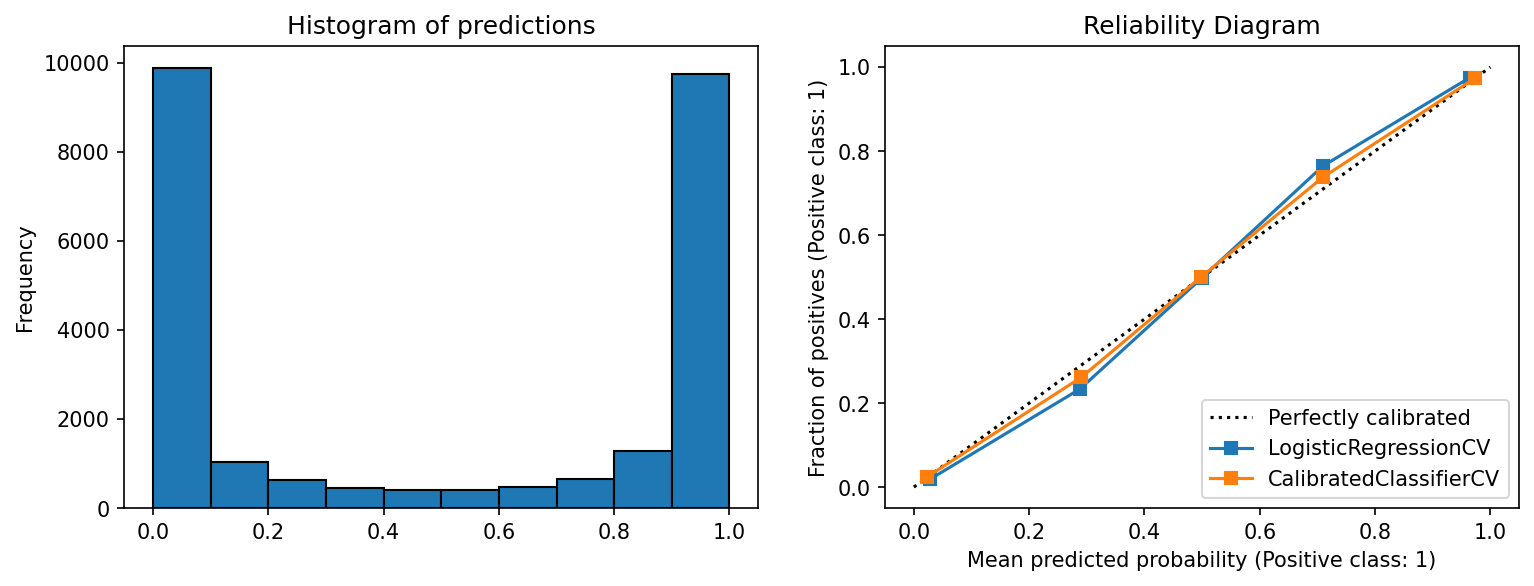

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=150)
df_test['y_test_pred'].plot(kind='hist', bins=np.arange(0, 1.1, 0.1),
                            edgecolor='k', ax=axes[0])
CalibrationDisplay.from_estimator(oracle, X_test, y_test, ax=axes[1])
CalibrationDisplay.from_estimator(calibrated_oracle, X_test, y_test, ax=axes[1])
axes[0].set_title("Histogram of predictions")
axes[1].set_title("Reliability Diagram")
plt.show(fig)

In [12]:
from sklearn.metrics import classification_report

In [13]:
from rich.console import Console

console = Console()

console.rule("[bold green]Train[/bold green]")
console.print(
    classification_report(
        y_train, oracle.predict(X_train),
        target_names=['negative', 'positive'],
        digits=4,
    )
)

console.rule("[bold green]Test[/bold green]")
console.print(
    classification_report(
        y_test, oracle.predict(X_test),
        target_names=['negative', 'positive'],
        digits=4,
    )
)

────────────────────────────────────────────────────── Train ──────────────────────────────────────────────────────

precision    recall  f1-score   support

    negative     0.9507    0.9419    0.9463     12500
    positive     0.9424    0.9511    0.9468     12500

    accuracy                         0.9465     25000
   macro avg     0.9466    0.9465    0.9465     25000
weighted avg     0.9466    0.9465    0.9465     25000

────────────────────────────────────────────────────── Test ───────────────────────────────────────────────────────

precision    recall  f1-score   support

    negative     0.9481    0.9424    0.9452     12500
    positive     0.9427    0.9484    0.9456     12500

    accuracy                         0.9454     25000
   macro avg     0.9454    0.9454    0.9454     25000
weighted avg     0.9454    0.9454    0.9454     25000

## Measuring Calibration of Synthetic Labels

### 1. Load Synthetic Data

In [14]:
load_dir = root_dir / "results/imdb/2025-05-08_02:41:02"  # soft + CoT
print("Model directory:", load_dir)
print(*os.listdir(load_dir), sep="\n")

Model directory: /home/hgkahng/Workspaces/soft-prompt/results/imdb/2025-05-08_02:41:02
template.jsonl
embeddings
config.yaml
data.jsonl
template_formatted.txt


In [15]:
# Print configurations

with open(load_dir / 'config.yaml') as f:
    cfg = yaml.safe_load(f)

style = "red" if cfg['hard'] else "green"

table = Table(title="Configuration(s)")
table.add_column("Name", justify="right", style="white", no_wrap=True)
table.add_column("Value", justify="left", style=style)
_ = [table.add_row(k, str(v)) for k, v in cfg.items()]

console = Console()
console.print(table);

         Configuration(s)          
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃         Name ┃ Value            ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│   batch_size │ 50               │
│          cot │ True             │
│         data │ imdb             │
│         hard │ False            │
│ log_interval │ 2                │
│   max_tokens │ 16384            │
│        model │ gemini-2.0-flash │
│ num_examples │ None             │
│  sample_size │ 50000            │
│  temperature │ 1.0              │
└──────────────┴──────────────────┘

In [16]:
with open(load_dir / 'template_formatted.txt') as f:
    template_example = "".join(f.readlines())

console.print(template_example)

system:
You are tasked with generating realistic movie reviews to train a sentiment classifier.
Use a sentiment scale from 0 (negative) to 1 (positive).
Reviews should generally be between 100 and 500 words, avoiding overly short or excessively long responses.
Before writing your final answer, please think step-by-step.
Ensure that you MUST provide your step-by-step thinking process in the final output.

human:
Generate a movie review with a sentiment score of 0.448.

In [17]:
with open(load_dir / "data.jsonl", "r") as f:
    data = [json.loads(line) for line in f]

print(len(data))

50017


In [18]:
labels = [d['label'] for d in data]
labels = np.array(labels)

hard_labels = (labels > 0.5).astype(int)
soft_labels = labels.copy()

print("Hard labels, shape:", hard_labels.shape)
print("Soft labels, shape:", soft_labels.shape)

Hard labels, shape: (50017,)
Soft labels, shape: (50017,)


In [19]:
embeddings = np.load(
    load_dir / "embeddings/openai/text-embedding-3-small/data.npy"
)
print(embeddings.shape)

(50017, 1536)


In [20]:
assert len(hard_labels) == embeddings.shape[0]
assert len(soft_labels) == embeddings.shape[0]

In [21]:
# downsample

N = 25_000

X_syn = embeddings.copy()[:N]
y_syn_hard = hard_labels.copy()[:N]
y_syn_soft = soft_labels.copy()[:N]

In [22]:
pd.Series(y_syn_hard).value_counts()

1    12710
0    12290
Name: count, dtype: int64

### 2. Vanilla

In [23]:
vanilla = LogisticRegressionCV(
    Cs=10, cv=5, solver='lbfgs', max_iter=1000, n_jobs=16,
    random_state=42, 
)
vanilla.fit(X_syn, y_syn_hard);

In [24]:
console.rule("[bold yellow] Synthetic [/bold yellow]")
console.print(
    classification_report(
        y_syn_hard, vanilla.predict(X_syn),
        target_names=['negative', 'positive'],
        digits=4,
    )
)

console.rule("[bold yellow] Test [/bold yellow]")
console.print(
    classification_report(
        y_test, vanilla.predict(X_test),
        target_names=['negative', 'positive'],
        digits=4,
    )
)

───────────────────────────────────────────────────  Synthetic  ───────────────────────────────────────────────────

precision    recall  f1-score   support

    negative     0.9901    0.9905    0.9903     12290
    positive     0.9908    0.9904    0.9906     12710

    accuracy                         0.9904     25000
   macro avg     0.9904    0.9904    0.9904     25000
weighted avg     0.9904    0.9904    0.9904     25000

─────────────────────────────────────────────────────  Test  ──────────────────────────────────────────────────────

precision    recall  f1-score   support

    negative     0.9565    0.8243    0.8855     12500
    positive     0.8456    0.9625    0.9003     12500

    accuracy                         0.8934     25000
   macro avg     0.9011    0.8934    0.8929     25000
weighted avg     0.9011    0.8934    0.8929     25000

In [25]:
df_test.head()

,y_test,y_test_pred
0,1,0.743328
1,1,0.998098
2,1,0.996770
3,1,0.972325
4,1,0.990776


In [26]:
df_test['y_test_vanilla_pred'] = vanilla.predict_proba(X_test)[:, 1]

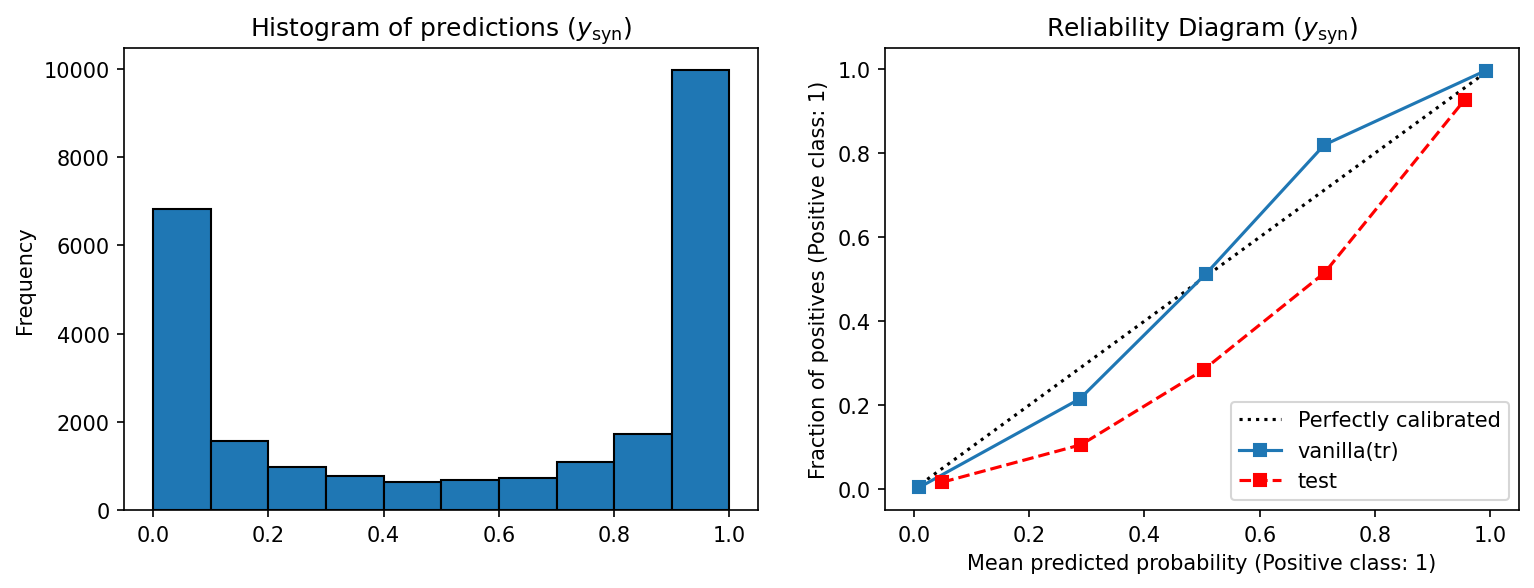

In [486]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=150)
df_test['y_test_vanilla_pred'].plot(kind='hist', bins=np.arange(0, 1.1, 0.1),
                                    edgecolor='k', ax=axes[0])
CalibrationDisplay.from_estimator(vanilla, X_syn, y_syn_hard, ax=axes[1], label='vanilla(tr)')
CalibrationDisplay.from_estimator(vanilla, X_test, y_test, ax=axes[1], linestyle='--', color='r', label='test')
axes[0].set_title(r"Histogram of predictions ($y_\text{syn}$)")
axes[1].set_title(r"Reliability Diagram ($y_\text{syn}$)")
plt.show(fig)

### 3. Measure Label Calibration
- Use $M_\text{oracle}$ to measure the quality of $y_\text{syn}$.
- $y_\text{oracle} = M_\text{oracle}(X_\text{syn})$
- $|y_\text{oracle} - y_\text{syn}|$

In [27]:
df_syn = pd.DataFrame.from_dict(
    {
        'y_syn': y_syn_soft,
        'y_syn_oracle': oracle.predict_proba(X_syn)[:, 1]
    }
)

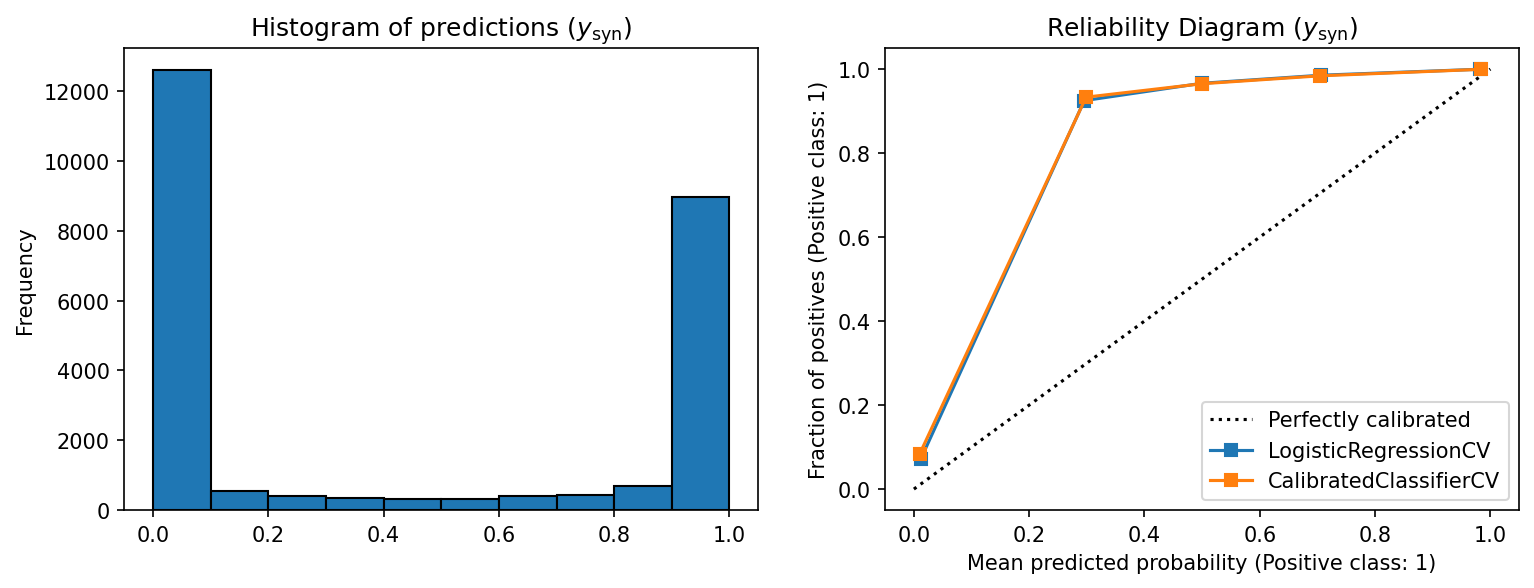

In [28]:
"""
    The uncalibrated reliability diagram below justifies the need for
    refinement of the generated soft labels.
"""

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=150)
df_syn['y_syn_oracle'].plot(kind='hist', bins=np.arange(0, 1.1, 0.1),
                            edgecolor='k', ax=axes[0])
CalibrationDisplay.from_estimator(oracle, X_syn, y_syn_hard, ax=axes[1])
CalibrationDisplay.from_estimator(calibrated_oracle, X_syn, y_syn_hard, ax=axes[1])
axes[0].set_title(r"Histogram of predictions ($y_\text{syn}$)")
axes[1].set_title(r"Reliability Diagram ($y_\text{syn}$)")
plt.show(fig)

/tmp/ipykernel_3927118/1234289607.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df_syn.groupby('bin_idx')['abs_diff'].mean()


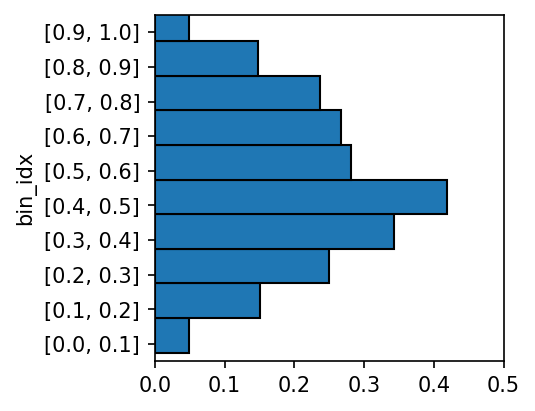

In [29]:
df_syn['abs_diff'] = (df_syn['y_syn'] - df_syn['y_syn_oracle']).abs()

bins = np.linspace(0, 1, 11)
bin_labels = [f"[{s:.1f}, {e:.1f}]" for s, e in zip(bins[:-1], bins[1:])]
df_syn['bin_idx'] = pd.cut(
    df_syn['y_syn'], bins=bins, labels=bin_labels, include_lowest=True,
)

bin_stats = df_syn.groupby('bin_idx')['abs_diff'].mean()

fig, ax = plt.subplots(1, 1, figsize=(3, 3), dpi=150)
bin_stats.plot(kind='barh', align='center', edgecolor='k', ax=ax)
for container in ax.containers:
    plt.setp(container, height=1.0)
ax.set_xlim(.0, 0.5)
plt.show(fig)

### 4. Refine with Oracle Model

In [30]:
model_oracle_refined = LogisticRegressionCV(
    Cs=10, cv=5, solver='lbfgs', max_iter=1000, n_jobs=16,
    random_state=42, 
)
model_oracle_refined.fit(X_syn, oracle.predict(X_syn));

In [31]:
model_oracle_refined.score(X_test, y_test)

0.92888

In [32]:
df_test.head()

,y_test,y_test_pred,y_test_vanilla_pred
0,1,0.743328,0.863035
1,1,0.998098,0.867760
2,1,0.996770,0.997574
3,1,0.972325,0.980838
4,1,0.990776,0.985547


In [33]:
df_test['y_test_oracle_refined_pred'] = model_oracle_refined.predict_proba(X_test)[:, 1]

In [34]:
df_test.head()

,y_test,y_test_pred,y_test_vanilla_pred,y_test_oracle_refined_pred
0,1,0.743328,0.863035,0.673639
1,1,0.998098,0.867760,0.996606
2,1,0.996770,0.997574,0.999376
3,1,0.972325,0.980838,0.996160
4,1,0.990776,0.985547,0.994794


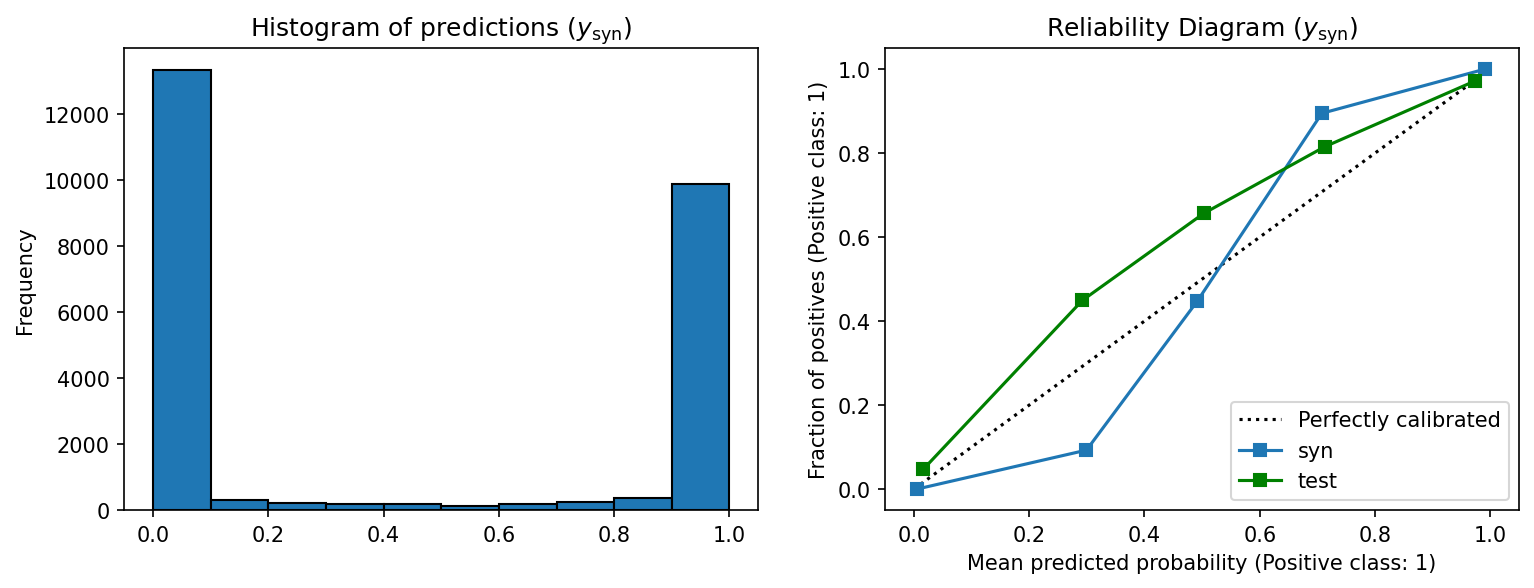

In [35]:
"""
    The uncalibrated reliability diagram below justifies the need for
    refinement of the generated soft labels.
"""

df_syn['y_syn_oracle_refined'] = model_oracle_refined.predict_proba(X_syn)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=150)
df_syn['y_syn_oracle_refined'].plot(kind='hist', bins=np.arange(0, 1.1, 0.1),
                                    edgecolor='k', ax=axes[0])

CalibrationDisplay.from_estimator(model_oracle_refined, X_syn, oracle.predict(X_syn), ax=axes[1], label='syn')
CalibrationDisplay.from_estimator(model_oracle_refined, X_test, y_test, ax=axes[1], color='g', label='test')
axes[0].set_title(r"Histogram of predictions ($y_\text{syn}$)")
axes[1].set_title(r"Reliability Diagram ($y_\text{syn}$)")
plt.show(fig)

### 4. Iterative Pseudo Labeling With Confidence Thresholding

In [36]:
y_syn_soft

array([0.77 , 0.848, 0.485, ..., 0.628, 0.943, 0.708], shape=(25000,))

In [37]:
y_syn_hard

array([1, 1, 0, ..., 1, 1, 1], shape=(25000,))

In [55]:
import numpy as np
from sklearn.linear_model import LogisticRegressionCV
from sklearn.exceptions import ConvergenceWarning
import warnings
# Import metrics
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score, brier_score_loss

def refine_soft_labels_iterative_granular_converge_eval(
    X_syn,
    y_syn_initial_soft,
    m_schedule,
    alpha_momentum=0.9,
    max_inner_iters=10,
    inner_convergence_tol=1e-5,
    ambiguous_region_convergence_tol=None,
    lr_cv_params=None,
    X_real_test=None,
    y_real_test=None,
    store_eval_history=True,
    verbose=True):
    """
    Refines soft labels iteratively, with granular inner convergence checks
    (total and ambiguous region), and optionally evaluates on a real test set.

    Args:
        X_syn (np.ndarray): Feature matrix of the synthetic data.
        y_syn_initial_soft (np.ndarray): Initial soft labels (probabilities 0 to 1).
        m_schedule (list or np.ndarray): List of margin values 'm' to iterate through.
        alpha_momentum (float): Momentum factor for label updates.
        max_inner_iters (int): Max iterations for the inner loop for each 'm'.
        inner_convergence_tol (float): Tolerance for *overall* label change.
        ambiguous_region_convergence_tol (float, optional): Specific tolerance for
            label change within the ambiguous region. If None, convergence relies
            primarily on inner_convergence_tol for overall change.
        lr_cv_params (dict, optional): Parameters for LogisticRegressionCV.
        X_real_test (np.ndarray, optional): Features of the real holdout test set.
        y_real_test (np.ndarray, optional): True labels of the real holdout test set.
        store_eval_history (bool): If True and test data is provided, stores and
                                   returns evaluation metrics from each inner iteration.
        verbose (bool): If True, prints progress information.


    Returns:
        np.ndarray: The refined soft labels.
        list: Evaluation history if store_eval_history is True and test data is provided.
    """
    if not (0.0 <= np.all(y_syn_initial_soft) <= 1.0):
        warnings.warn("Initial soft labels are not all between 0 and 1. Clipping them.")
        y_syn_soft_refined = np.clip(y_syn_initial_soft.copy(), 0.0, 1.0)
    else:
        y_syn_soft_refined = y_syn_initial_soft.copy()

    evaluation_history = []
    default_lr_cv_params = {
        'cv': 3, 'random_state': 42, 'solver': 'liblinear',
        'max_iter': 200, 'scoring': 'neg_log_loss', 'Cs': 10
    }
    if lr_cv_params is None:
        lr_cv_params = default_lr_cv_params.copy()
    else:
        for key, value in default_lr_cv_params.items():
            lr_cv_params.setdefault(key, value)

    effective_tol_for_print = ambiguous_region_convergence_tol if ambiguous_region_convergence_tol is not None else inner_convergence_tol
    log_tol = np.log10(effective_tol_for_print) if effective_tol_for_print > 0 else -10 # Avoid log(0)
    print_precision = abs(int(log_tol)) + 2 if log_tol < 0 else 3


    can_evaluate_on_test = X_real_test is not None and y_real_test is not None

    for m_idx, m in enumerate(m_schedule):
        if verbose:
            print(f"\n--- Outer Loop: Processing m = {m:.3f} (Stage {m_idx+1}/{len(m_schedule)}) ---")

        for inner_iter in range(max_inner_iters):
            y_at_inner_iter_start = y_syn_soft_refined.copy()

            confident_mask_at_iter_start = (y_at_inner_iter_start <= 0.5 - m) | \
                                           (y_at_inner_iter_start >= 0.5 + m)
            ambiguous_mask_at_iter_start = (y_at_inner_iter_start > 0.5 - m) & \
                                           (y_at_inner_iter_start < 0.5 + m)

            X_hc = X_syn[confident_mask_at_iter_start]
            y_hc_hard = (y_at_inner_iter_start[confident_mask_at_iter_start] > 0.5).astype(int)

            num_hc_samples = X_hc.shape[0]
            num_ambiguous_to_update = np.sum(ambiguous_mask_at_iter_start)


            if verbose > 1:
                print(f"  Inner Iter {inner_iter+1}/{max_inner_iters} for m={m:.3f}:")
                print(f"    HC samples (start of iter): {num_hc_samples}, Ambiguous to update: {num_ambiguous_to_update}")
                if num_hc_samples > 0:
                    counts = np.bincount(y_hc_hard, minlength=2)
                    print(f"    HC class dist (0/1): {counts[0]}/{counts[1] if len(counts)>1 else 0}")

            min_samples_per_class_for_cv = lr_cv_params.get('cv', 3)
            can_train = False
            if num_hc_samples > 0:
                unique_classes_hc, class_counts_hc = np.unique(y_hc_hard, return_counts=True)
                if len(unique_classes_hc) >= 2 and np.all(class_counts_hc >= min_samples_per_class_for_cv):
                    can_train = True

            if not can_train:
                if verbose:
                    print(f"  Inner Iter {inner_iter+1}: Not enough data/classes in HC set to train for m={m:.3f}. "
                          f"Breaking inner loop for this m.")
                break

            model = LogisticRegressionCV(**lr_cv_params)
            try:
                with warnings.catch_warnings():
                    warnings.filterwarnings("ignore", category=ConvergenceWarning)
                    warnings.filterwarnings("ignore", category=UserWarning, message="Liblinear failed to converge*")
                    model.fit(X_hc, y_hc_hard)
            except ValueError as e:
                if verbose:
                    print(f"  Inner Iter {inner_iter+1}: Error training LogisticRegressionCV for m={m:.3f}: {e}. "
                          f"Breaking inner loop.")
                break

            if can_evaluate_on_test:
                try:
                    y_pred_test_proba = model.predict_proba(X_real_test)
                    y_pred_test_hard = model.predict(X_real_test)
                    acc = accuracy_score(y_real_test, y_pred_test_hard)
                    ll = log_loss(y_real_test, y_pred_test_proba) # Rely on default eps
                    auc = roc_auc_score(y_real_test, y_pred_test_proba[:, 1])
                    brier = brier_score_loss(y_real_test, y_pred_test_proba[:, 1])
                    if verbose:
                        print(f"    Test Perf @ m={m:.3f}, inner_iter={inner_iter+1}: "
                              f"Acc={acc:.4f}, LogLoss={ll:.4f}, AUC={auc:.4f}, Brier={brier:.4f}")
                    if store_eval_history:
                        evaluation_history.append({
                            'm': m, 'inner_iter': inner_iter + 1, 'test_accuracy': acc,
                            'test_log_loss': ll, 'test_auc': auc, 'test_brier': brier,
                            'num_hc_samples': num_hc_samples, 'num_ambiguous_samples_updated': num_ambiguous_to_update
                        })
                except Exception as e:
                    if verbose: print(f"    Error during test set evaluation: {e}")

            if num_ambiguous_to_update > 0:
                X_to_predict = X_syn[ambiguous_mask_at_iter_start]
                try:
                    y_pred_ambiguous_soft = model.predict_proba(X_to_predict)[:, 1]
                    y_pred_clipped = np.clip(y_pred_ambiguous_soft, 0.0, 1.0)
                    
                    y_syn_soft_refined[ambiguous_mask_at_iter_start] = \
                        alpha_momentum * y_at_inner_iter_start[ambiguous_mask_at_iter_start] + \
                        (1 - alpha_momentum) * y_pred_clipped
                    y_syn_soft_refined[ambiguous_mask_at_iter_start] = \
                        np.clip(y_syn_soft_refined[ambiguous_mask_at_iter_start], 0.0, 1.0)
                except Exception as e:
                    if verbose: print(f"  Inner Iter {inner_iter+1}: Error predicting/updating for m={m:.3f}: {e}")
            elif verbose > 1:
                print(f"  Inner Iter {inner_iter+1}: No ambiguous samples (defined at start of iter) to update for m={m:.3f}.")


            mean_total_label_change = np.mean(np.abs(y_syn_soft_refined - y_at_inner_iter_start))
            mean_abs_change_ambiguous_region = 0.0
            if num_ambiguous_to_update > 0:
                mean_abs_change_ambiguous_region = np.mean(
                    np.abs(y_syn_soft_refined[ambiguous_mask_at_iter_start] -
                           y_at_inner_iter_start[ambiguous_mask_at_iter_start])
                )
            num_confident_at_start = np.sum(confident_mask_at_iter_start)
            mean_abs_change_confident_region = 0.0 # Should remain 0
            if num_confident_at_start > 0:
                mean_abs_change_confident_region = np.mean(
                    np.abs(y_syn_soft_refined[confident_mask_at_iter_start] -
                           y_at_inner_iter_start[confident_mask_at_iter_start])
                )

            if verbose:
                print(f"  Inner Iter {inner_iter+1}/{max_inner_iters} for m={m:.3f}:")
                print(f"    Mean Total Change          = {mean_total_label_change:.{print_precision}f}")
                if num_ambiguous_to_update > 0:
                    print(f"    Mean Ambiguous Region Change = {mean_abs_change_ambiguous_region:.{print_precision}f} (for {num_ambiguous_to_update} samples)")
                else:
                    print(f"    No ambiguous samples were targeted for update in this step.")
                print(f"    Mean Confident Region Change = {mean_abs_change_confident_region:.{print_precision}f} (for {num_confident_at_start} samples)")


            converged_this_iter = False
            if ambiguous_region_convergence_tol is not None:
                if num_ambiguous_to_update > 0: # Only consider if ambiguous samples were targeted
                    if mean_abs_change_ambiguous_region < ambiguous_region_convergence_tol:
                        if verbose: print(f"  Ambiguous region converged (change < {ambiguous_region_convergence_tol:.{print_precision}f}).")
                        converged_this_iter = True
                elif num_ambiguous_to_update == 0: # No ambiguous samples to begin with for this iter
                    if verbose: print(f"  No ambiguous samples to update, considering ambiguous part converged for this iteration.")
                    # If no ambiguous samples, this specific criterion might be met by default for this part
                    # but we should still rely on overall change or max_iters.
                    # Let's ensure that if ambiguous_region_convergence_tol is the main driver,
                    # this case means the "ambiguous" part is done.
                    converged_this_iter = True # Ambiguous part is "done" as there's nothing to do.
            
            if not converged_this_iter and (mean_total_label_change < inner_convergence_tol):
                if verbose:
                    print(f"  Overall label change ({mean_total_label_change:.{print_precision}f}) below threshold ({inner_convergence_tol:.{print_precision}f}).")
                converged_this_iter = True

            if converged_this_iter:
                if verbose: print(f"  Inner convergence met for m={m:.3f} after {inner_iter+1} iterations.")
                break
            elif inner_iter == max_inner_iters - 1 and verbose:
                print(f"  Max inner iterations ({max_inner_iters}) reached for m={m:.3f}.")

    if verbose:
        print("\n--- Iterative refinement with granular convergence and optional evaluation complete ---")
    return y_syn_soft_refined, evaluation_history if store_eval_history and can_evaluate_on_test else None

In [56]:
# (Assuming X_syn_sample, y_syn_initial_sample, m_schedule_example,
#  X_real_test_sample, y_real_test_sample exist)

refined_labels, eval_hist = refine_soft_labels_iterative_granular_converge_eval(
    X_syn,
    y_syn_soft,
    m_schedule,
    alpha_momentum=0.9,
    max_inner_iters=15, # Can be slightly higher if using specific tol
    inner_convergence_tol=1e-5,  # For overall change
    ambiguous_region_convergence_tol=5e-5, # Specific tol for ambiguous region change
    X_real_test=X_test,
    y_real_test=y_test,
    verbose=True # Use verbose=2 for more detailed mask/distribution prints
)

# Analyze eval_hist and refined_labels
if eval_hist:
    import pandas as pd
    df_history = pd.DataFrame(eval_hist)
    print(df_history.tail())


--- Outer Loop: Processing m = 0.400 (Stage 1/12) ---
    Test Perf @ m=0.400, inner_iter=1: Acc=0.8271, LogLoss=0.4089, AUC=0.9725, Brier=0.1253
  Inner Iter 1/15 for m=0.400:
    Mean Total Change          = 0.022569
    Mean Ambiguous Region Change = 0.028226 (for 19990 samples)
    Mean Confident Region Change = 0.000000 (for 5010 samples)
    Test Perf @ m=0.400, inner_iter=2: Acc=0.8460, LogLoss=0.3651, AUC=0.9731, Brier=0.1115
  Inner Iter 2/15 for m=0.400:
    Mean Total Change          = 0.019881
    Mean Ambiguous Region Change = 0.025596 (for 19418 samples)
    Mean Confident Region Change = 0.000000 (for 5582 samples)
    Test Perf @ m=0.400, inner_iter=3: Acc=0.8693, LogLoss=0.3107, AUC=0.9740, Brier=0.0944
  Inner Iter 3/15 for m=0.400:
    Mean Total Change          = 0.017477
    Mean Ambiguous Region Change = 0.023248 (for 18794 samples)
    Mean Confident Region Change = 0.000000 (for 6206 samples)
    Test Perf @ m=0.400, inner_iter=4: Acc=0.8757, LogLoss=0.2977, AU

KeyboardInterrupt: 

In [53]:
import numpy as np
from sklearn.linear_model import LogisticRegressionCV
from sklearn.exceptions import ConvergenceWarning
import warnings
# Import metrics
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score, brier_score_loss

def refine_soft_labels_iterative_converge_eval(
    X_syn,
    y_syn_initial_soft,
    m_schedule,
    alpha_momentum=0.9,
    max_inner_iters=10,
    inner_convergence_tol=1e-5,
    lr_cv_params=None,
    X_real_test=None, # New: Real test features
    y_real_test=None, # New: Real test labels
    store_eval_history=True, # New: Flag to store eval history
    verbose=True):
    """
    Refines soft labels iteratively, with inner convergence, and optionally
    evaluates the intermediate refinement model on a real test set.

    Args:
        # ... (previous args) ...
        X_real_test (np.ndarray, optional): Features of the real holdout test set.
        y_real_test (np.ndarray, optional): True labels of the real holdout test set.
        store_eval_history (bool): If True and test data is provided, stores and
                                   returns evaluation metrics from each inner iteration.
        verbose (bool): If True, prints progress information.


    Returns:
        np.ndarray: The refined soft labels.
        list: A list of dictionaries containing evaluation history if
              store_eval_history is True and test data is provided. Otherwise, None.
    """
    if not (0.0 <= np.all(y_syn_initial_soft) <= 1.0):
        warnings.warn("Initial soft labels are not all between 0 and 1. Clipping them.")
        y_syn_soft_refined = np.clip(y_syn_initial_soft.copy(), 0.0, 1.0)
    else:
        y_syn_soft_refined = y_syn_initial_soft.copy()

    n_samples = X_syn.shape[0]
    evaluation_history = []

    default_lr_cv_params = {
        'cv': 3, 'random_state': 42, 'solver': 'liblinear',
        'max_iter': 200, 'scoring': 'neg_log_loss', 'Cs': 10
    }
    if lr_cv_params is None:
        lr_cv_params = default_lr_cv_params.copy()
    else:
        for key, value in default_lr_cv_params.items():
            lr_cv_params.setdefault(key, value)

    log_tol = np.log10(inner_convergence_tol) if inner_convergence_tol > 0 else -10
    print_precision = abs(int(log_tol)) + 2 if log_tol < 0 else 3

    # Determine if test set evaluation can be performed
    can_evaluate_on_test = X_real_test is not None and y_real_test is not None

    for m_idx, m in enumerate(m_schedule):
        if verbose:
            print(f"\n--- Outer Loop: Processing m = {m:.3f} (Stage {m_idx+1}/{len(m_schedule)}) ---")

        for inner_iter in range(max_inner_iters):
            y_at_inner_iter_start = y_syn_soft_refined.copy()

            current_high_confidence_mask = (y_syn_soft_refined <= 0.5 - m) | \
                                           (y_syn_soft_refined >= 0.5 + m)
            current_ambiguous_mask = (y_syn_soft_refined > 0.5 - m) & \
                                     (y_syn_soft_refined < 0.5 + m)

            X_hc = X_syn[current_high_confidence_mask]
            y_hc_soft = y_syn_soft_refined[current_high_confidence_mask]
            y_hc_hard = (y_hc_soft > 0.5).astype(int)

            num_hc_samples = X_hc.shape[0]
            num_ambiguous_samples_current_step = np.sum(current_ambiguous_mask)

            if verbose > 1:
                print(f"  Inner Iter {inner_iter+1}/{max_inner_iters} for m={m:.3f}:")
                print(f"    HC samples: {num_hc_samples}, Ambiguous samples: {num_ambiguous_samples_current_step}")
                if num_hc_samples > 0:
                    counts = np.bincount(y_hc_hard, minlength=2) # Ensure length 2 for bincount
                    print(f"    HC class dist (0/1): {counts[0]}/{counts[1] if len(counts)>1 else 0}")


            min_samples_per_class_for_cv = lr_cv_params.get('cv', 3)
            can_train = False
            if num_hc_samples > 0:
                unique_classes_hc, class_counts_hc = np.unique(y_hc_hard, return_counts=True)
                if len(unique_classes_hc) >= 2 and np.all(class_counts_hc >= min_samples_per_class_for_cv):
                    can_train = True

            if not can_train:
                if verbose:
                    print(f"  Inner Iter {inner_iter+1}: Not enough data/classes in HC set to train for m={m:.3f}. "
                          f"Breaking inner loop for this m.")
                break

            model = LogisticRegressionCV(**lr_cv_params)
            try:
                with warnings.catch_warnings():
                    warnings.filterwarnings("ignore", category=ConvergenceWarning)
                    warnings.filterwarnings("ignore", category=UserWarning, message="Liblinear failed to converge*")
                    model.fit(X_hc, y_hc_hard)
            except ValueError as e:
                if verbose:
                    print(f"  Inner Iter {inner_iter+1}: Error training LogisticRegressionCV for m={m:.3f}: {e}. "
                          f"Breaking inner loop.")
                break

            # --- Test Set Evaluation Point ---
            if can_evaluate_on_test:
                try:
                    y_pred_test_proba = model.predict_proba(X_real_test)
                    y_pred_test_hard = model.predict(X_real_test) # For accuracy

                    acc = accuracy_score(y_real_test, y_pred_test_hard)
                    ll = log_loss(y_real_test, y_pred_test_proba)
                    auc = roc_auc_score(y_real_test, y_pred_test_proba[:, 1]) # Prob of positive class
                    brier = brier_score_loss(y_real_test, y_pred_test_proba[:, 1])


                    if verbose:
                        print(f"    Test Perf @ m={m:.3f}, inner_iter={inner_iter+1}: "
                              f"Acc={acc:.4f}, LogLoss={ll:.4f}, AUC={auc:.4f}, Brier={brier:.4f}")

                    if store_eval_history:
                        current_metrics = {
                            'm': m, 'inner_iter': inner_iter + 1,
                            'test_accuracy': acc, 'test_log_loss': ll,
                            'test_auc': auc, 'test_brier': brier,
                            'num_hc_samples': num_hc_samples,
                            'num_ambiguous_samples': num_ambiguous_samples_current_step
                        }
                        evaluation_history.append(current_metrics)
                except Exception as e:
                    if verbose:
                        print(f"    Error during test set evaluation for m={m:.3f}, inner_iter={inner_iter+1}: {e}")
            # --- End Test Set Evaluation ---

            if num_ambiguous_samples_current_step > 0:
                X_ambiguous_current_step = X_syn[current_ambiguous_mask]
                try:
                    y_pred_ambiguous_soft = model.predict_proba(X_ambiguous_current_step)[:, 1]
                    y_pred_ambiguous_soft_clipped = np.clip(y_pred_ambiguous_soft, 0.0, 1.0)
                    
                    y_syn_soft_refined[current_ambiguous_mask] = \
                        alpha_momentum * y_at_inner_iter_start[current_ambiguous_mask] + \
                        (1 - alpha_momentum) * y_pred_ambiguous_soft_clipped
                    y_syn_soft_refined[current_ambiguous_mask] = np.clip(y_syn_soft_refined[current_ambiguous_mask], 0.0, 1.0)

                except Exception as e:
                    if verbose:
                        print(f"  Inner Iter {inner_iter+1}: Error predicting/updating for m={m:.3f}: {e}")
            elif verbose > 1:
                print(f"  Inner Iter {inner_iter+1}: No ambiguous samples to update for m={m:.3f}.")
                if inner_iter > 0: break


            mean_label_change = np.mean(np.abs(y_syn_soft_refined - y_at_inner_iter_start))

            if verbose: # Always print this main convergence metric for the inner loop
                 print(f"  Inner Iter {inner_iter+1}/{max_inner_iters} for m={m:.3f}: "
                      f"Mean label change = {mean_label_change:.{print_precision}f}")

            if mean_label_change < inner_convergence_tol:
                if verbose:
                    print(f"  Inner convergence reached for m={m:.3f} after {inner_iter+1} iterations.")
                break
            elif inner_iter == max_inner_iters - 1 and verbose:
                print(f"  Max inner iterations ({max_inner_iters}) reached for m={m:.3f}.")

    if verbose:
        print("\n--- Iterative refinement with inner convergence and optional evaluation complete ---")

    return y_syn_soft_refined, evaluation_history if store_eval_history and can_evaluate_on_test else None

In [54]:
# (Assuming X_syn_sample, y_syn_initial_sample, m_schedule_example exist)
# (Assuming X_real_test_sample, y_real_test_sample also exist)

m_start = 0.4
m_end = 0.05
num_steps = 12
m_schedule = np.linspace(m_start, m_end, num_steps).tolist()

refined_labels, eval_hist = refine_soft_labels_iterative_converge_eval(
    X_syn,
    y_syn_soft,
    m_schedule,
    alpha_momentum=0.9,
    max_inner_iters=10,
    inner_convergence_tol=1e-5,
    X_real_test=X_test,  # Pass your real test features
    y_real_test=y_test,  # Pass your real test labels
    store_eval_history=True,
    verbose=True
)

if eval_hist:
    print("\nEvaluation History (first 5 entries):")
    for i, record in enumerate(eval_hist[:5]):
        print(record)
    # You can convert eval_hist to a pandas DataFrame for easier analysis/plotting
    # import pandas as pd
    # df_eval_hist = pd.DataFrame(eval_hist)
    # print(df_eval_hist.head())
    # df_eval_hist.plot(x='m', y=['test_accuracy', 'test_auc', 'test_log_loss'], kind='line', subplots=True)


--- Outer Loop: Processing m = 0.400 (Stage 1/12) ---
    Test Perf @ m=0.400, inner_iter=1: Acc=0.8271, LogLoss=0.4089, AUC=0.9725, Brier=0.1253
  Inner Iter 1/10 for m=0.400: Mean label change = 0.0225694
    Test Perf @ m=0.400, inner_iter=2: Acc=0.8460, LogLoss=0.3651, AUC=0.9731, Brier=0.1115
  Inner Iter 2/10 for m=0.400: Mean label change = 0.0198808
    Test Perf @ m=0.400, inner_iter=3: Acc=0.8693, LogLoss=0.3107, AUC=0.9740, Brier=0.0944
  Inner Iter 3/10 for m=0.400: Mean label change = 0.0174770
    Test Perf @ m=0.400, inner_iter=4: Acc=0.8757, LogLoss=0.2977, AUC=0.9739, Brier=0.0902
  Inner Iter 4/10 for m=0.400: Mean label change = 0.0154684
    Test Perf @ m=0.400, inner_iter=5: Acc=0.8862, LogLoss=0.2778, AUC=0.9744, Brier=0.0837
  Inner Iter 5/10 for m=0.400: Mean label change = 0.0137762
    Test Perf @ m=0.400, inner_iter=6: Acc=0.8898, LogLoss=0.2706, AUC=0.9744, Brier=0.0813
  Inner Iter 6/10 for m=0.400: Mean label change = 0.0121913
    Test Perf @ m=0.400, in

KeyboardInterrupt: 

In [38]:
import numpy as np
from sklearn.linear_model import LogisticRegressionCV
from sklearn.exceptions import ConvergenceWarning
import warnings

def refine_soft_labels_iterative(X_syn,
                                 y_syn_initial_soft,
                                 m_schedule,
                                 alpha=.9,
                                 lr_cv_params=None,
                                 verbose: bool = True,
                                 X_test: np.ndarray = None,
                                 y_test: np.ndarray = None):
    """
    Refines soft labels iteratively using LogisticRegressionCV.

    Args:
        X_syn (np.ndarray): Feature matrix of the synthetic data.
        y_syn_initial_soft (np.ndarray): Initial soft labels (probabilities between 0 and 1).
        m_schedule (list or np.ndarray): A list of margin values 'm' to iterate through,
                                         e.g., [0.4, 0.3, 0.2, 0.1, 0.0].
                                         The values should generally decrease.
        lr_cv_params (dict, optional): Parameters to pass to LogisticRegressionCV.
                                       Defaults to {'cv': 3, 'random_state': 42,
                                                    'solver': 'liblinear', 'max_iter': 200,
                                                    'scoring':'neg_log_loss'}.
                                       'scoring' is set to 'neg_log_loss' to favor
                                       well-calibrated probabilities.
        verbose (bool): If True, prints progress information.

    Returns:
        np.ndarray: The refined soft labels.
    """
    if not (0.0 <= np.all(y_syn_initial_soft) <= 1.0):
        warnings.warn("Initial soft labels are not all between 0 and 1. Clipping them.")
        y_syn_soft_refined = np.clip(y_syn_initial_soft.copy(), 0.0, 1.0)
    else:
        y_syn_soft_refined = y_syn_initial_soft.copy()

    n_samples = X_syn.shape[0]

    if lr_cv_params is None:
        lr_cv_params = {
            'cv': 5,  # Using a smaller CV for potentially smaller high-confidence sets
            'random_state': 42,
            'solver': 'lbfgs', # Often good for smaller datasets
            'max_iter': 1000,
            'scoring': 'accuracy' # Encourages better probability estimates
        }
    # Ensure 'Cs' is reasonable if not provided, especially for liblinear
    if 'Cs' not in lr_cv_params and lr_cv_params.get('solver') in ('liblinear', 'lbfgs'):
        lr_cv_params['Cs'] = 10 # Default Cs for LogisticRegressionCV

    if isinstance(X_test, np.ndarray) and isinstance(y_test, np.ndarray):
        model = LogisticRegressionCV(**lr_cv_params)
        model.fit(X_syn, (y_syn_soft > 0.5).astype(int));
        print(f"Test accuracy before refinement: {model.score(X_test, y_test):.4f}")

    for i, m in enumerate(m_schedule):
        if verbose:
            print(f"\n--- Iteration {i+1} with m = {m:.3f} ---")

        # Identify high-confidence and ambiguous regions based on current soft labels
        # High-confidence: labels are far from 0.5
        high_confidence_mask = (y_syn_soft_refined <= 0.5 - m) | (y_syn_soft_refined >= 0.5 + m)
        # Ambiguous: labels are close to 0.5
        # Ensure strict inequality for ambiguous to avoid overlap if m=0 and label is exactly 0.5
        ambiguous_mask = (y_syn_soft_refined > 0.5 - m) & (y_syn_soft_refined < 0.5 + m)

        X_hc = X_syn[high_confidence_mask]
        y_hc_soft = y_syn_soft_refined[high_confidence_mask]

        # Convert soft labels in high-confidence set to hard labels for LogisticRegressionCV training
        y_hc_hard = (y_hc_soft > 0.5).astype(int)

        num_hc_samples = X_hc.shape[0]
        num_ambiguous_samples = np.sum(ambiguous_mask)

        if verbose:
            print(f"High-confidence samples: {num_hc_samples}")
            print(f"Ambiguous samples: {num_ambiguous_samples}")
            if num_hc_samples > 0:
                counts = np.bincount(y_hc_hard, minlength=2)
                print(f"High-confidence class distribution (0/1): {counts[0]}/{counts[1]}")

        if num_hc_samples == 0:
            if verbose:
                print("No high-confidence samples found for this m. Skipping training.")
            continue # No data to train on

        # Check if training is feasible (enough samples and classes for CV)
        unique_classes, class_counts = np.unique(y_hc_hard, return_counts=True)
        min_samples_per_class_for_cv = lr_cv_params.get('cv', 3) # Get cv value

        if len(unique_classes) < 2:
            if verbose:
                print(f"Only one class ({unique_classes[0]}) present in high-confidence set ({num_hc_samples} samples). Skipping training for m={m:.3f}.")
            continue
        if np.any(class_counts < min_samples_per_class_for_cv):
             if verbose:
                print(f"Not enough samples in each class for CV (cv={min_samples_per_class_for_cv}). Min found: {np.min(class_counts)}. Skipping training for m={m:.3f}.")
             # Potentially reduce CV folds or skip. For now, skipping.
             # A more advanced version could try to reduce cv adaptively.
             continue


        # Train the refinement model
        model = LogisticRegressionCV(**lr_cv_params)
        try:
            with warnings.catch_warnings(): # Suppress convergence warnings if they are not critical for user
                warnings.filterwarnings(
                    "ignore", category=ConvergenceWarning)
                warnings.filterwarnings(
                    "ignore", category=UserWarning, message="Liblinear failed to converge*") # Common with liblinear
                model.fit(X_hc, y_hc_hard)
        except ValueError as e:
            if verbose:
                print(f"Error training LogisticRegressionCV for m={m:.3f}: {e}. Skipping this iteration.")
            continue

        if isinstance(X_test, np.ndarray) and isinstance(y_test, np.ndarray):
            test_acc = model.score(X_test, y_test)
            print(f"({i}) Test accuracy: {test_acc:.4f}")

        if num_ambiguous_samples > 0:
            X_ambiguous = X_syn[ambiguous_mask]
            

        # Predict on ambiguous samples
        if num_ambiguous_samples > 0:
            X_ambiguous = X_syn[ambiguous_mask]
            try:
                y_pred_ambiguous_soft = model.predict_proba(X_ambiguous)[:, 1] # Prob of positive class

                # Update the soft labels for the ambiguous region
                y_syn_soft_refined[ambiguous_mask] = \
                    alpha * y_syn_soft_refined[ambiguous_mask] + \
                        (1-alpha) * y_pred_ambiguous_soft
                if verbose:
                    # Check min/max of newly predicted labels
                    if len(y_pred_ambiguous_soft) > 0:
                        print(f"Updated {num_ambiguous_samples} ambiguous labels. New labels min/max: {np.min(y_pred_ambiguous_soft):.3f}/{np.max(y_pred_ambiguous_soft):.3f}")
                    else:
                        print("No ambiguous samples had predictions made (empty prediction array).")

            except Exception as e:
                if verbose:
                    print(f"Error predicting on ambiguous samples for m={m:.3f}: {e}")
        elif verbose:
            print("No ambiguous samples to predict for this m.")

    if verbose:
        print("\n--- Iterative refinement complete ---")
    
    return y_syn_soft_refined

In [39]:
# Define the schedule for 'm' - typically decreasing
m_schedule = [0.4, 0.4, 0.4, 0.3, 0.3, 0.3, 0.25, 0.25, 0.25, 0.20, 0.20, 0.20]  # Start with wider margin

m_start = 0.4
m_end = 0.05
num_steps = 12
m_schedule = np.linspace(m_start, m_end, num_steps).tolist()

# Define LogisticRegressionCV parameters (optional, defaults are provided)
# Using a smaller CV fold due to potentially small high-confidence sets initially
custom_lr_params = {
    'cv': 5,
    'random_state': 42,
    'solver': 'lbfgs', # 'liblinear' is good for smaller datasets
    'max_iter': 1000,       # Increased max_iter
    'scoring': 'accuracy', # Focus on probability calibration
    'Cs': np.logspace(-3, 1, 7) # Example of Cs range
}

# Run the refinement
y_syn_self_refined = refine_soft_labels_iterative(
    X_syn,
    y_syn_soft,
    m_schedule,
    lr_cv_params=custom_lr_params, # Using custom params
    verbose=True,
    X_test=X_test,
    y_test=y_test,
    alpha=0.99,
)

Test accuracy before refinement: 0.8908

--- Iteration 1 with m = 0.400 ---
High-confidence samples: 5010
Ambiguous samples: 19990
High-confidence class distribution (0/1): 2511/2499
(0) Test accuracy: 0.8314
Updated 19990 ambiguous labels. New labels min/max: 0.401/0.591

--- Iteration 2 with m = 0.368 ---
High-confidence samples: 6468
Ambiguous samples: 18532
High-confidence class distribution (0/1): 3226/3242
(1) Test accuracy: 0.8666
Updated 18532 ambiguous labels. New labels min/max: 0.385/0.611

--- Iteration 3 with m = 0.336 ---
High-confidence samples: 7925
Ambiguous samples: 17075
High-confidence class distribution (0/1): 3968/3957
(2) Test accuracy: 0.8725
Updated 17075 ambiguous labels. New labels min/max: 0.367/0.627

--- Iteration 4 with m = 0.305 ---
High-confidence samples: 9460
Ambiguous samples: 15540
High-confidence class distribution (0/1): 4702/4758
(3) Test accuracy: 0.8975
Updated 15540 ambiguous labels. New labels min/max: 0.356/0.643

--- Iteration 5 with m = 0.

In [40]:
y_syn_soft

array([0.77 , 0.848, 0.485, ..., 0.628, 0.943, 0.708], shape=(25000,))

In [41]:
y_syn_self_refined

array([0.76473245, 0.8424374 , 0.44847727, ..., 0.63775252, 0.943     ,
       0.70660808], shape=(25000,))

In [42]:
model_self_refined = LogisticRegressionCV(
    Cs=10, cv=5, solver='lbfgs', max_iter=1000, n_jobs=16,
    random_state=42, 
)

y_syn_self_refined_hard = (y_syn_self_refined > 0.5).astype(int) 
model_self_refined.fit(X_syn, y_syn_self_refined_hard);

In [43]:
model_self_refined.score(X_syn, y_syn_self_refined_hard)  # training acc

0.99224

In [44]:
model_self_refined.score(X_train, y_train)

0.89384

In [45]:
model_self_refined.score(X_test, y_test)

0.89356

In [46]:
df_test.head()

,y_test,y_test_pred,y_test_vanilla_pred,y_test_oracle_refined_pred
0,1,0.743328,0.863035,0.673639
1,1,0.998098,0.867760,0.996606
2,1,0.996770,0.997574,0.999376
3,1,0.972325,0.980838,0.996160
4,1,0.990776,0.985547,0.994794


In [47]:
df_test['y_test_pred_self_refined_pred'] = model_self_refined.predict_proba(X_test)[:, 1]

In [48]:
df_test.head()

,y_test,y_test_pred,y_test_vanilla_pred,y_test_oracle_refined_pred,y_test_pred_self_refined_pred
0,1,0.743328,0.863035,0.673639,0.863284
1,1,0.998098,0.867760,0.996606,0.868409
2,1,0.996770,0.997574,0.999376,0.997745
3,1,0.972325,0.980838,0.996160,0.978195
4,1,0.990776,0.985547,0.994794,0.985250


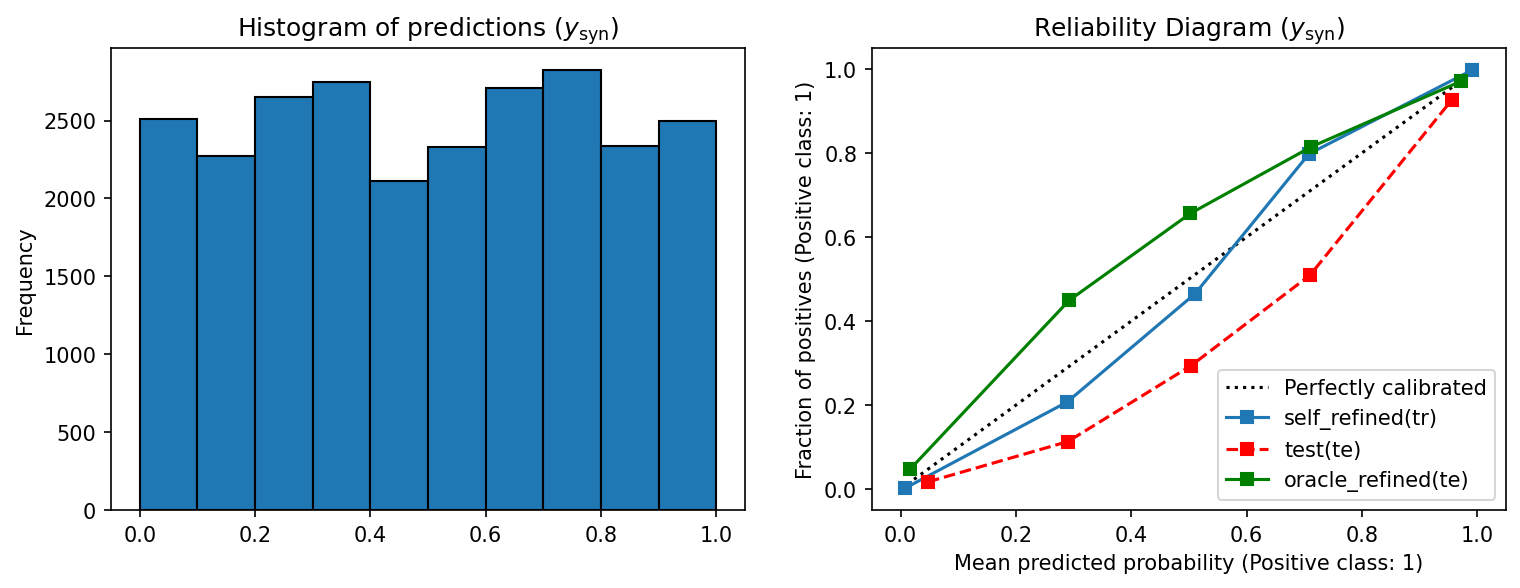

In [49]:
df_syn['y_syn_self_refined'] = y_syn_self_refined

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=150)
df_syn['y_syn_self_refined'].plot(kind='hist', bins=np.arange(0, 1.1, 0.1),
                                  edgecolor='k', ax=axes[0])

CalibrationDisplay.from_estimator(
    model_self_refined, X_syn, y_syn_self_refined_hard, ax=axes[1], label='self_refined(tr)')
CalibrationDisplay.from_estimator(
    model_self_refined, X_test, y_test, ax=axes[1], color='r', linestyle='--', label='test(te)')
CalibrationDisplay.from_predictions(
    y_true=y_test, y_prob=df_test['y_test_oracle_refined_pred'], color='g', label='oracle_refined(te)', ax=axes[1],
)
axes[0].set_title(r"Histogram of predictions ($y_\text{syn}$)")
axes[1].set_title(r"Reliability Diagram ($y_\text{syn}$)")
plt.show(fig)

/tmp/ipykernel_3927118/4239089159.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df_syn.groupby('bin_idx')['abs_diff_self_refined'].mean()


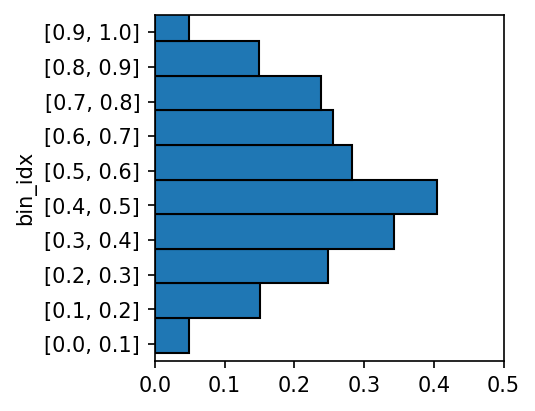

In [50]:
df_syn['abs_diff_self_refined'] = (df_syn['y_syn_self_refined'] - df_syn['y_syn_oracle']).abs()

bins = np.linspace(0, 1, 11)
bin_labels = [f"[{s:.1f}, {e:.1f}]" for s, e in zip(bins[:-1], bins[1:])]
df_syn['bin_idx'] = pd.cut(
    df_syn['y_syn_self_refined'], bins=bins, labels=bin_labels, include_lowest=True,
)

bin_stats = df_syn.groupby('bin_idx')['abs_diff_self_refined'].mean()

fig, ax = plt.subplots(1, 1, figsize=(3, 3), dpi=150)
bin_stats.plot(kind='barh', align='center', edgecolor='k', ax=ax)
for container in ax.containers:
    plt.setp(container, height=1.0)
ax.set_xlim(.0, 0.5)
plt.show(fig)